In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

RANDOM_STATE = None

NON_EXCHANGEABLE_THRESHOLD = 100 # 20 or 100 in the paper


def generate_exchangeable_data(n_samples=500):
    """
    Generate i.i.d. exchangeable labeled data.

    Data are sampled from two Gaussian classes with overlapping distributions.
    Order is randomized → exchangeable sequence.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...] where X_i is 2D, y_i in {0,1}
    """
    n0 = n_samples // 2
    n1 = n_samples - n0

    # make classes closer together to have meaningful alpha_i
    X0 = np.random.normal(loc=(-0.5, 0), scale=1.0, size=(n0, 2))
    X1 = np.random.normal(loc=(0.5, 0), scale=1.0, size=(n1, 2))

    y0 = np.zeros(n0, dtype=int)
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    dataset = list(zip(X, y))
    np.random.shuffle(dataset)  # crucial for exchangeability

    return dataset


def generate_time_series_data(n_samples=500):
    """
    Generate non-exchangeable time series data.

    Distribution drifts smoothly over time.
    This violates exchangeability but preserves local structure.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...] where X_i is 2D (time + value), y_i in {0,1}
    """
    X = []
    y = []

    for t in range(n_samples):
        # drifting mean (smooth sinusoidal)
        mean = np.sin(t / 50)

        x_val = np.random.normal(loc=mean, scale=0.5)

        # label based on deviation from current mean → dynamic structure
        label = int(x_val > mean)

        X.append([t, x_val])
        y.append(label)

    dataset = list(zip(np.array(X), np.array(y)))
    return dataset


def generate_step_change_data(n_samples=500):
    """
    Generate non-exchangeable data with abrupt change.

    First half of data from one Gaussian, second half from another.
    Useful for testing sudden non-exchangeability.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...]
    """
    n0 = n_samples // 2
    n1 = n_samples - n0

    # first half: mean -1
    X0 = np.random.normal(loc=-1, scale=0.5, size=(n0, 2))
    y0 = np.zeros(n0, dtype=int)

    # second half: mean +1
    X1 = np.random.normal(loc=1, scale=0.5, size=(n1, 2))
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    dataset = list(zip(X, y))
    return dataset


def generate_two_gaussian_abrupt_shift(n_samples=500, prop_late_change=0.2):
    """
    Generates data from two classes, each class from a different Gaussian.
    For the last prop_late_change of timesteps, the Gaussian means change abruptly.

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...]
        X_i: shape (2,), y_i in {0,1}
    """
    n_change = int(n_samples * (1 - prop_late_change))
    n_after = n_samples - n_change

    # First phase
    mean0_1 = np.array([0, 0])
    mean1_1 = np.array([2, 2])
    cov = np.eye(2) * 0.4

    X0_1 = np.random.multivariate_normal(mean0_1, cov, size=n_change//2)
    X1_1 = np.random.multivariate_normal(mean1_1, cov, size=n_change - n_change//2)

    # After abrupt mean shift
    mean0_2 = np.array([0, -5])
    mean1_2 = np.array([2, -3])

    n0_after = n_after // 2
    n1_after = n_after - n0_after
    X0_2 = np.random.multivariate_normal(mean0_2, cov, size=n0_after)
    X1_2 = np.random.multivariate_normal(mean1_2, cov, size=n1_after)

    # Shuffle data within each phase
    # Phase 1 (before shift)
    X_1 = np.vstack([X0_1, X1_1])
    y_1 = np.array([0] * len(X0_1) + [1] * len(X1_1))
    idx_1 = np.random.permutation(len(X_1))
    X_1 = X_1[idx_1]
    y_1 = y_1[idx_1]

    # Phase 2 (after shift)
    X_2 = np.vstack([X0_2, X1_2])
    y_2 = np.array([0] * len(X0_2) + [1] * len(X1_2))
    idx_2 = np.random.permutation(len(X_2))
    X_2 = X_2[idx_2]
    y_2 = y_2[idx_2]

    # Concatenate in time order: before the shift, then after the shift
    X = np.vstack([X_1, X_2])
    y = np.concatenate([y_1, y_2])

    dataset = list(zip(X, y))
    return dataset

def generate_two_gaussian_slow_shift(
    n_samples=500,
    mean0_start=np.array([0, 0]),
    mean0_end=np.array([0, -5]),
    mean1_start=np.array([2, 2]),
    mean1_end=np.array([2, -3]),
    cov=None,
    prop_late_change=0.2
):
    """
    Generates data from two classes, each class from a different Gaussian whose means drift slowly (linearly)
    from their start to end positions, but the shift only occurs at the last prop_late_change proportion
    of timesteps (default: 20%).

    Returns
    -------
    dataset : list of tuples
        [(X_i, y_i), ...]
        X_i: shape (2,), y_i in {0,1}
    """
    if cov is None:
        cov = np.eye(2) * 0.4
    X = []
    y = []

    n_shift_start = int(n_samples * (1 - prop_late_change))

    for t in range(n_samples):
        if t < n_shift_start:
            frac = 0
        else:
            denom = max(1, n_samples - n_shift_start - 1)
            frac = (t - n_shift_start) / denom
        mean0_t = mean0_start * (1 - frac) + mean0_end * frac
        mean1_t = mean1_start * (1 - frac) + mean1_end * frac

        label = np.random.randint(0, 2)
        if label == 0:
            X_t = np.random.multivariate_normal(mean0_t, cov)
        else:
            X_t = np.random.multivariate_normal(mean1_t, cov)
        X.append(X_t)
        y.append(label)
    dataset = list(zip(np.array(X), np.array(y)))
    return dataset


exchangeable = generate_exchangeable_data()
timeseries = generate_time_series_data()
stepchange = generate_step_change_data()
abrupt_shift = generate_two_gaussian_abrupt_shift()
slowly_changing = generate_two_gaussian_slow_shift()

X_ex = np.array([x for x, y in exchangeable])
y_ex = np.array([y for x, y in exchangeable])
X_ts = np.array([x for x, y in timeseries])
y_ts = np.array([y for x, y in timeseries])
X_sc = np.array([x for x, y in stepchange])
y_sc = np.array([y for x, y in stepchange])
X_abrupt = np.array([x for x, y in abrupt_shift])
y_abrupt = np.array([y for x, y in abrupt_shift])
X_slow = np.array([x for x, y in slowly_changing])
y_slow = np.array([y for x, y in slowly_changing])

In [2]:

# For exchangeable data
X_ex_trainval, X_ex_test, y_ex_trainval, y_ex_test = train_test_split(X_ex, y_ex, test_size=0.3, random_state=RANDOM_STATE, stratify=y_ex)
X_ex_train, X_ex_test_online, y_ex_train, y_ex_test_online = train_test_split(X_ex_trainval, y_ex_trainval, test_size=0.5, random_state=RANDOM_STATE, stratify=y_ex_trainval)

# For time series data (do chronological split, not random)
n = len(X_ts)
n_train = int(n * 0.7)
n_test = int(n * 0.15)
n_test_online = n - n_train - n_test
X_ts_train, y_ts_train = X_ts[:n_train], y_ts[:n_train]
X_ts_test, y_ts_test = X_ts[n_train:n_train + n_test], y_ts[n_train:n_train + n_test]
X_ts_test_online, y_ts_test_online = X_ts[n_train + n_test:], y_ts[n_train + n_test:]

# For step change data
X_sc_trainval, X_sc_test, y_sc_trainval, y_sc_test = train_test_split(X_sc, y_sc, test_size=0.3, random_state=RANDOM_STATE, stratify=y_sc)
X_sc_train, X_sc_test_online, y_sc_train, y_sc_test_online = train_test_split(X_sc_trainval, y_sc_trainval, test_size=0.5, random_state=RANDOM_STATE, stratify=y_sc_trainval)

# For abrupt shift data
X_abrupt_trainval, X_abrupt_test, y_abrupt_trainval, y_abrupt_test = train_test_split(X_abrupt, y_abrupt, test_size=0.3, random_state=RANDOM_STATE, shuffle=False)
X_abrupt_train, X_abrupt_test_online, y_abrupt_train, y_abrupt_test_online = train_test_split(X_abrupt_trainval, y_abrupt_trainval, test_size=0.5, random_state=RANDOM_STATE, shuffle=False)

# For slowly changing gaussian data
X_slow_trainval, X_slow_test, y_slow_trainval, y_slow_test = train_test_split(X_slow, y_slow, test_size=0.3, random_state=RANDOM_STATE, shuffle=False)
X_slow_train, X_slow_test_online, y_slow_train, y_slow_test_online = train_test_split(X_slow_trainval, y_slow_trainval, test_size=0.5, random_state=RANDOM_STATE, shuffle=False)


# Simple training wrapper for sklearn LogisticRegression
def train_and_evaluate(X, y):
    model = LogisticRegression()
    model.fit(X, y)
    score = model.score(X, y)
    print(f"Training accuracy: {score:.3f}")
    return model

# Example usage:
print("Training on exchangeable data:")
model_ex = train_and_evaluate(X_ex_train, y_ex_train)

print("Training on time series data:")
model_ts = train_and_evaluate(X_ts_train, y_ts_train)

print("Training on step change data:")
model_sc = train_and_evaluate(X_sc_train, y_sc_train)

print("Training on abrupt shift data:")
model_abrupt = train_and_evaluate(X_abrupt_train, y_abrupt_train)

print("Training on slowly changing gaussian data:")
model_slow = train_and_evaluate(X_slow_train, y_slow_train)


Training on exchangeable data:
Training accuracy: 0.691
Training on time series data:
Training accuracy: 0.729
Training on step change data:
Training accuracy: 1.000
Training on abrupt shift data:
Training accuracy: 0.977
Training on slowly changing gaussian data:
Training accuracy: 0.989


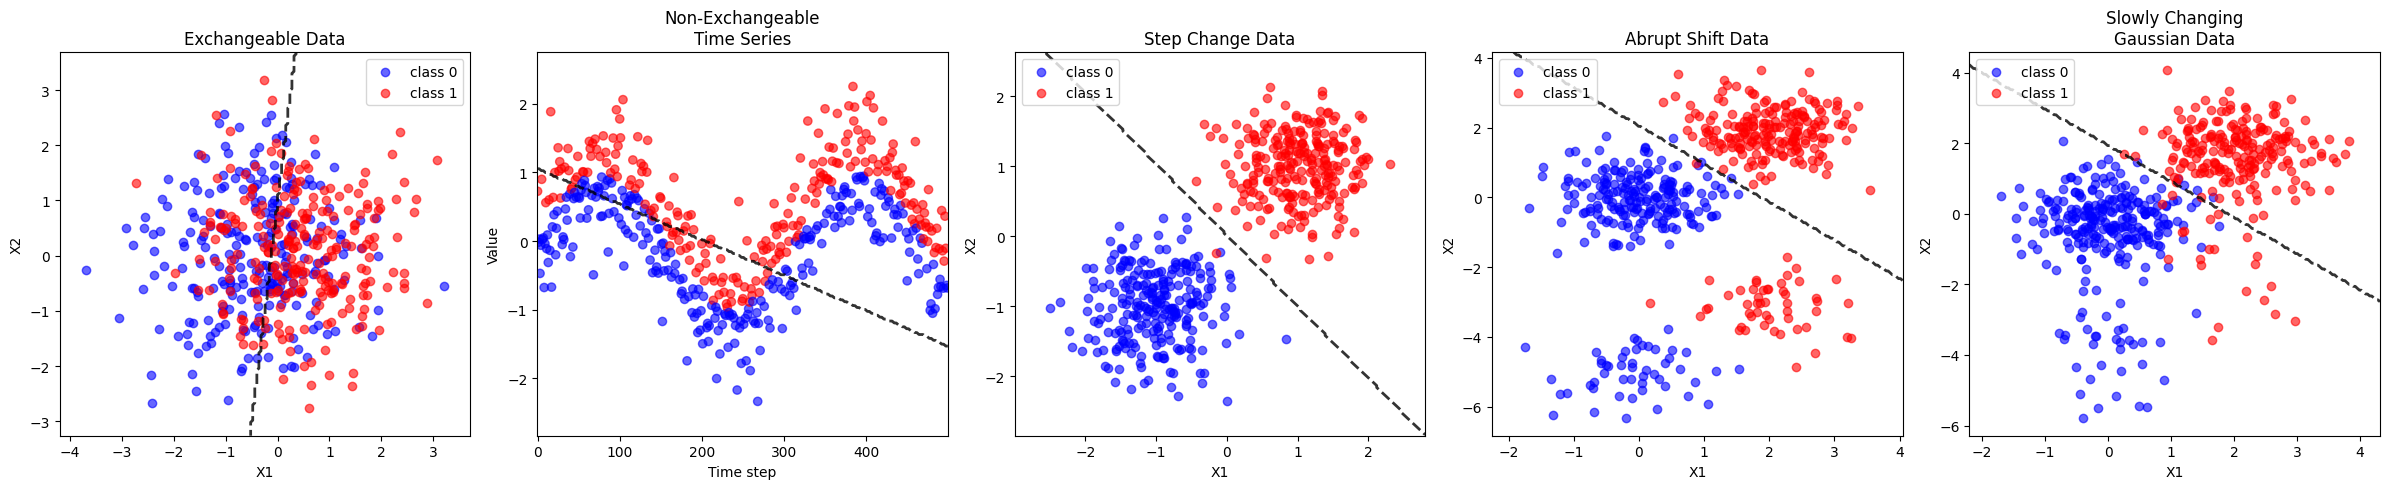

In [3]:
def plot_decision_boundary(ax, model, X, color='k', linewidth=2, linestyle='--'):
    # Only plot for 2D features
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    try:
        Z = model.predict(grid)
    except Exception:
        # If model can't do predict, skip
        return
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5], colors=color, linewidths=linewidth, linestyles=linestyle, alpha=0.8)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# Exchangeable data
axes[0].scatter(X_ex[y_ex==0][:,0], X_ex[y_ex==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[0].scatter(X_ex[y_ex==1][:,0], X_ex[y_ex==1][:,1], c='red', label='class 1', alpha=0.6)
plot_decision_boundary(axes[0], model_ex, X_ex)
axes[0].set_title("Exchangeable Data")
axes[0].legend()
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")

# Time series (non-exchangeable)
axes[1].scatter(X_ts[:,0], X_ts[:,1], c=y_ts, cmap='bwr', alpha=0.6)
plot_decision_boundary(axes[1], model_ts, X_ts)
axes[1].set_title("Non-Exchangeable\nTime Series")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Value")

# Step change data (abrupt non-exchangeable)
axes[2].scatter(X_sc[y_sc==0][:,0], X_sc[y_sc==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[2].scatter(X_sc[y_sc==1][:,0], X_sc[y_sc==1][:,1], c='red', label='class 1', alpha=0.6)
plot_decision_boundary(axes[2], model_sc, X_sc)
axes[2].set_title("Step Change Data")
axes[2].legend()
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")

# Abrupt shift data
axes[3].scatter(X_abrupt[y_abrupt==0][:,0], X_abrupt[y_abrupt==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[3].scatter(X_abrupt[y_abrupt==1][:,0], X_abrupt[y_abrupt==1][:,1], c='red', label='class 1', alpha=0.6)
plot_decision_boundary(axes[3], model_abrupt, X_abrupt)
axes[3].set_title("Abrupt Shift Data")
axes[3].legend()
axes[3].set_xlabel("X1")
axes[3].set_ylabel("X2")

# Slowly changing gaussian data
axes[4].scatter(X_slow[y_slow==0][:,0], X_slow[y_slow==0][:,1], c='blue', label='class 0', alpha=0.6)
axes[4].scatter(X_slow[y_slow==1][:,0], X_slow[y_slow==1][:,1], c='red', label='class 1', alpha=0.6)
plot_decision_boundary(axes[4], model_slow, X_slow)
axes[4].set_title("Slowly Changing\nGaussian Data")
axes[4].legend()
axes[4].set_xlabel("X1")
axes[4].set_ylabel("X2")

plt.tight_layout()
plt.show()

# Tracking the risk of a deployed model and detecting harmful distribution shifts  Aleksandr Podkopaev, Aaditya Ramdas 2022

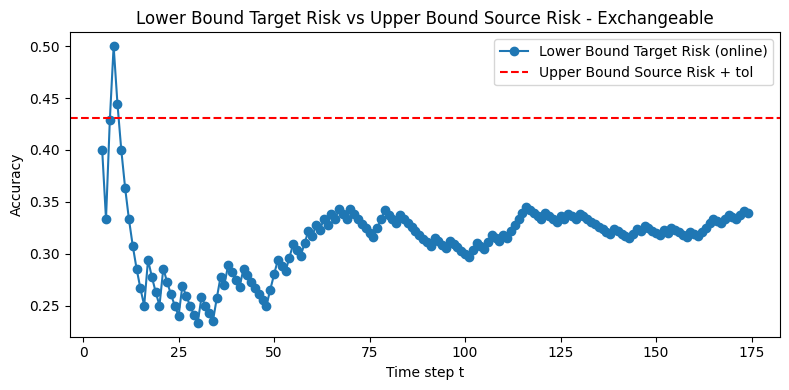

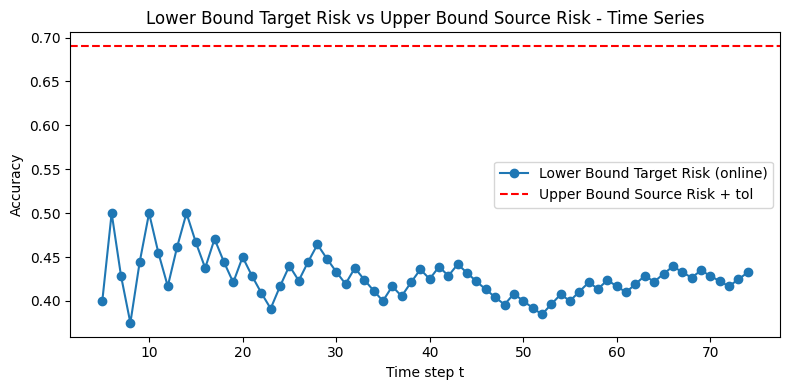

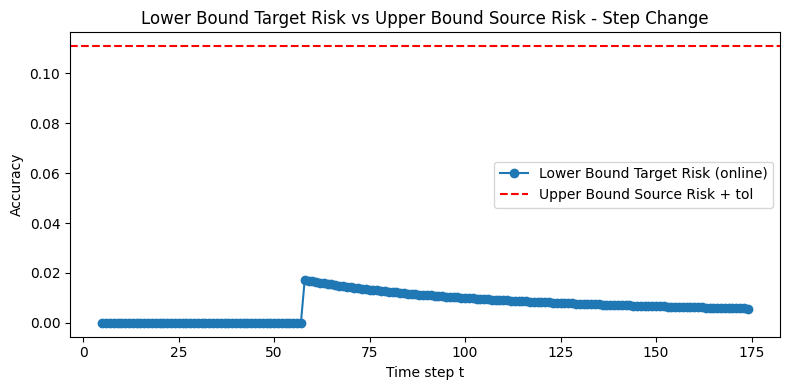

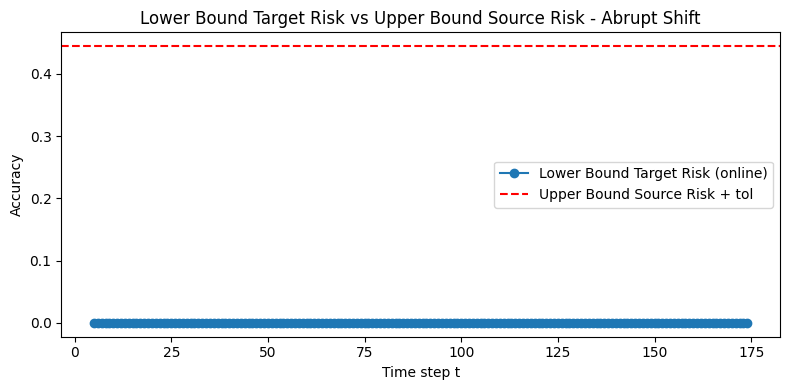

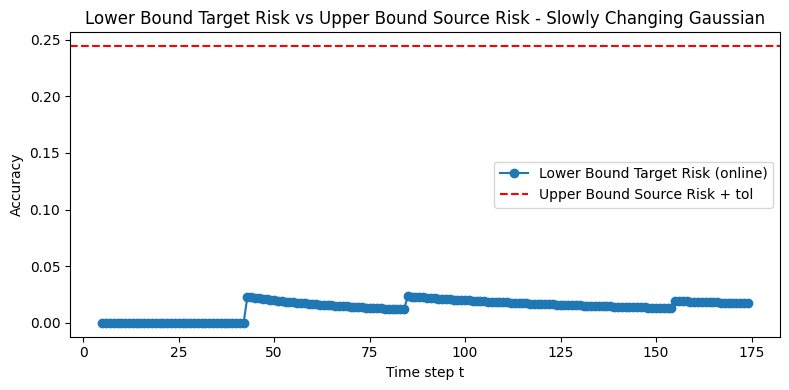

In [4]:
datasets = [
    {
        "name": "Exchangeable",
        "X_test": X_ex_test,
        "y_test": y_ex_test,
        "X_test_online": X_ex_test_online,
        "y_test_online": y_ex_test_online,
        "model": model_ex,
    },
    {
        "name": "Time Series",
        "X_test": X_ts_test,
        "y_test": y_ts_test,
        "X_test_online": X_ts_test_online,
        "y_test_online": y_ts_test_online,
        "model": model_ts,
    },
    {
        "name": "Step Change",
        "X_test": X_sc_test,
        "y_test": y_sc_test,
        "X_test_online": X_sc_test_online,
        "y_test_online": y_sc_test_online,
        "model": model_sc,
    },
    {
        "name": "Abrupt Shift",
        "X_test": X_abrupt_test,
        "y_test": y_abrupt_test,
        "X_test_online": X_abrupt_test_online,
        "y_test_online": y_abrupt_test_online,
        "model": model_abrupt,
    },
    {
        "name": "Slowly Changing Gaussian",
        "X_test": X_slow_test,
        "y_test": y_slow_test,
        "X_test_online": X_slow_test_online,
        "y_test_online": y_slow_test_online,
        "model": model_slow,
    }
]

for data in datasets:
    X_test = data["X_test"]
    y_test = data["y_test"]
    X_test_online = data["X_test_online"]
    y_test_online = data["y_test_online"]
    model = data["model"]
    

    delta = 0.05 # desired type I error
    delta_source = delta / 2
    tol = 0

    empirical_source_risk = 1 - model.score(X_test, y_test) # accuracy, risk, etc. on the source distribution
    upper_correction = np.sqrt(np.log(1/delta_source) / (2 * len(X_test))) # PM-H bound
    upper_bound_source_risk = empirical_source_risk + upper_correction

    t_warmup = 5 # initialisation to avoid warnings in the early iterations: need to check the original code on how they handle that
    lower_bound_target_risk_history = []
    shift_detected_history = []
    for t in range(t_warmup, len(X_test_online)):
        
        X_history = X_test_online[:t]
        y_history = y_test_online[:t]

        if t == t_warmup:
            empirical_target_risk_t = 1 - model.score(X_test_online[:t], y_test_online[:t])
        else:
            empirical_target_risk_t = (t-1) / t * empirical_target_risk_t + 1 / t * (1 - model.score(X_test_online[t:t+1], y_test_online[t:t+1]))  # accuracy, risk, etc. on the target distribution
        lower_correction = 0 # should compute CM-EB (using an external package) which handles time-varying mean (bound adapted to online data slowly drifting to non i.i.d)
        lower_bound_target_risk_t = empirical_target_risk_t - lower_correction
        
        if lower_bound_target_risk_t > upper_bound_source_risk + tol:
            shift_detected_history.append(True)
        else:
            shift_detected_history.append(False)
        
        lower_bound_target_risk_history.append(lower_bound_target_risk_t)



    plt.figure(figsize=(8, 4))
    plt.plot(range(t_warmup, t_warmup + len(lower_bound_target_risk_history)), lower_bound_target_risk_history, label="Lower Bound Target Risk (online)", marker='o')
    plt.axhline(y=upper_bound_source_risk + tol, color='r', linestyle='--', label="Upper Bound Source Risk + tol")
    plt.xlabel("Time step t")
    plt.ylabel("Accuracy")
    plt.title(f"Lower Bound Target Risk vs Upper Bound Source Risk - {data['name']}")
    plt.legend()
    plt.tight_layout()
    plt.show()


    

# Prediction-Powered Risk Monitoring of Deployed Models for Detecting Harmful  Distribution Shifts

In [5]:
# Similar algo as SRM above but different bounds, and and a risk estimation which leverages a combinatin of true labels and synthetic labels from a predictor (PPI method)